# Importing Libraries

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

# Test set Image Processing

In [5]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'dataset/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True
)
class_name = validation_set.class_names
print(class_name)


Found 17572 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Tw

# Loading Model

In [6]:
cnn = tf.keras.models.load_model('trained_plant_disease_model.keras')

# Visualising and Performing Prediction on Single image

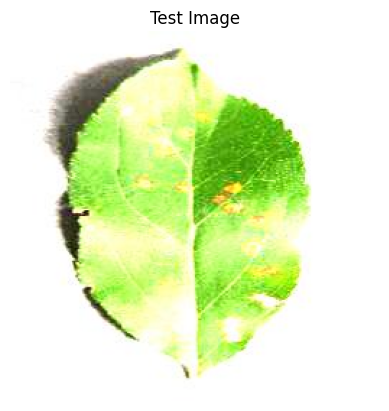

In [14]:
import cv2
import matplotlib.pyplot as plt

image_path = r'C:\Users\SRV\Projeto_Agrcultura_De_Precisao\Plant_Disease_Prediction\dataset\test\AppleCedarRust1.JPG'

# Lendo e exibindo a imagem
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Converter BGR → RGB

plt.imshow(img)
plt.title('Test Image')
plt.axis('off')
plt.show()


## Testing Model

In [15]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step


In [16]:
print(predictions)

[[6.1378664e-13 2.2602118e-11 1.0000000e+00 4.2541044e-14 5.4575515e-12
  3.7095771e-13 2.6694376e-17 3.2409754e-12 3.2265822e-18 1.4890809e-15
  7.6208247e-21 2.2387507e-11 9.3833239e-14 1.3722610e-15 6.3100316e-14
  4.4272993e-14 9.0507594e-11 3.0591117e-14 1.3674922e-12 3.1749173e-14
  1.5366638e-14 2.5455815e-14 3.3674597e-12 8.7777016e-15 3.6662000e-16
  6.2395365e-15 3.8099534e-13 5.7858152e-15 1.2694041e-09 1.2399745e-13
  1.6928324e-12 4.0114337e-15 2.2938833e-11 1.1107478e-16 1.6131020e-11
  8.7183394e-14 1.7433429e-13 2.0407853e-12]]


In [17]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

2


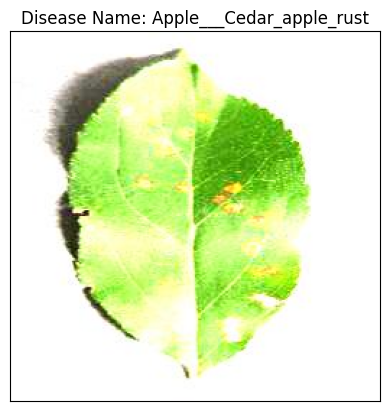

In [18]:
# Displaying the disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()